### Importando dados do limpeza_e_tratamento.ipynb

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

caminho = r'c:\Users\Enuk\OneDrive\Documents\Enuk\Cursos\Python\Projeto Steam data\SteamGames_clean.csv'
df = pd.read_csv(caminho)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29916 entries, 0 to 29915
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Appid              29916 non-null  int64  
 1   Name               29916 non-null  str    
 2   Type               29916 non-null  str    
 3   ReleaseDate        29916 non-null  str    
 4   Genres             29916 non-null  str    
 5   Developers         29891 non-null  str    
 6   Publishers         28872 non-null  str    
 7   Description        29864 non-null  str    
 8   price              29916 non-null  float64
 9   Thumbnail          29916 non-null  str    
 10  Tags               29916 non-null  str    
 11  ReviewScore        29916 non-null  int64  
 12  PositiveReview     29916 non-null  int64  
 13  NegativeReview     29916 non-null  int64  
 14  OsRequirement      29916 non-null  str    
 15  MemoryRequirement  29916 non-null  str    
 16  CpuRequirement     29916 non-null

### Criando o gráfico de total de vendas por Distribuidora.

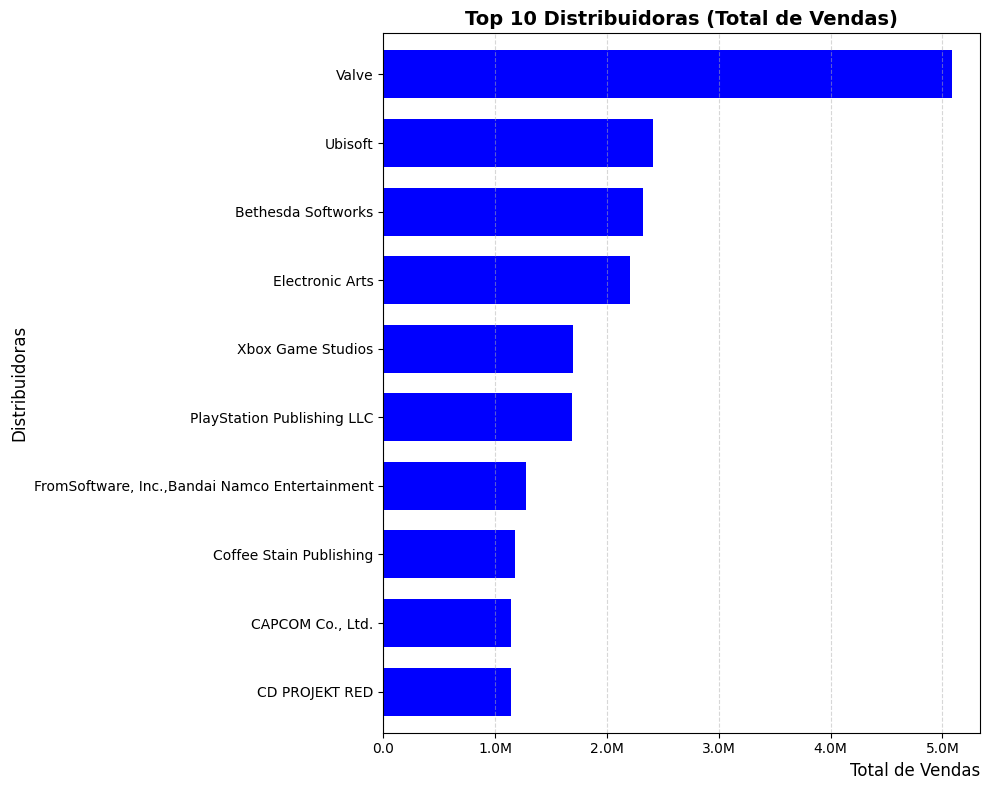

In [29]:
df_grouped = df.groupby('Publishers')[['Total_de_Vendas']].sum()
df_ordenado = df_grouped.sort_values(by='Total_de_Vendas', ascending=True).tail(10)
fig, ax = plt.subplots(figsize=(10, 8)) 
df_ordenado.plot(kind='barh', ax=ax, color='blue', legend=False, width=0.7)

def formatar_numero(valor, pos):
    if valor >= 1_000_000:
        return f'{valor/1_000_000:.1f}M'
    elif valor >= 1_000:
        return f'{valor/1_000:.0f}k'
    return str(valor)
    
ax.xaxis.set_major_formatter(FuncFormatter(formatar_numero))

plt.title('Top 10 Distribuidoras (Total de Vendas)', fontsize=14, fontweight='bold')
plt.xlabel('Total de Vendas', fontsize=12, loc='right') 
plt.ylabel('Distribuidoras', fontsize=12)

ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [32]:
df_eficiencia = df.groupby('Publishers').agg({'price': 'mean', 'Total_de_Vendas': 'sum'})
print(df_eficiencia.head(10))

                                     price  Total_de_Vendas
Publishers                                                 
                                      9.99            466.0
505 Games                            39.99          32824.0
727 Not Hound                         5.99             20.0
Appnori Inc.                         19.99            590.0
Arbatskii Anatolii                   14.99             20.0
Bold Head Interactive                14.99             16.0
ChaosGalaxyStudio                     1.99             54.0
ChillyRoom                            4.99             30.0
Cow Games                            39.99            114.0
CreativeForge Games,Vincennes Group  19.99            336.0


### Análise por gênero baseado no número de vendas

<Axes: ylabel='Genres'>

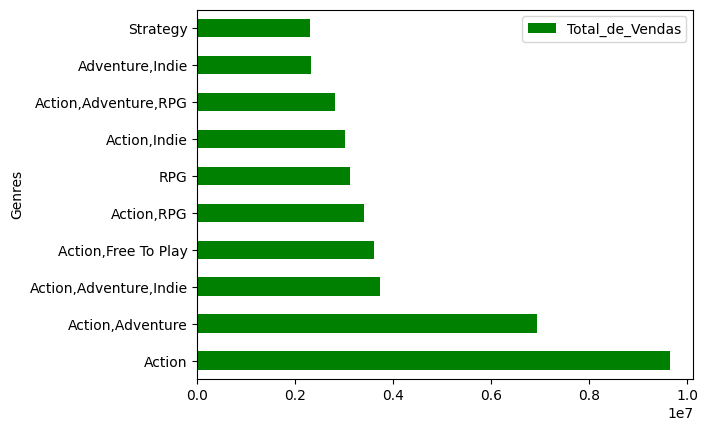

In [ ]:

generos = df.groupby('Genres')[['Total_de_Vendas']].sum().sort_values(by='Total_de_Vendas', ascending=False).head(10)
generos.plot(kind='barh', color='green')

### Participação de lucro dentro da plataforma Steam

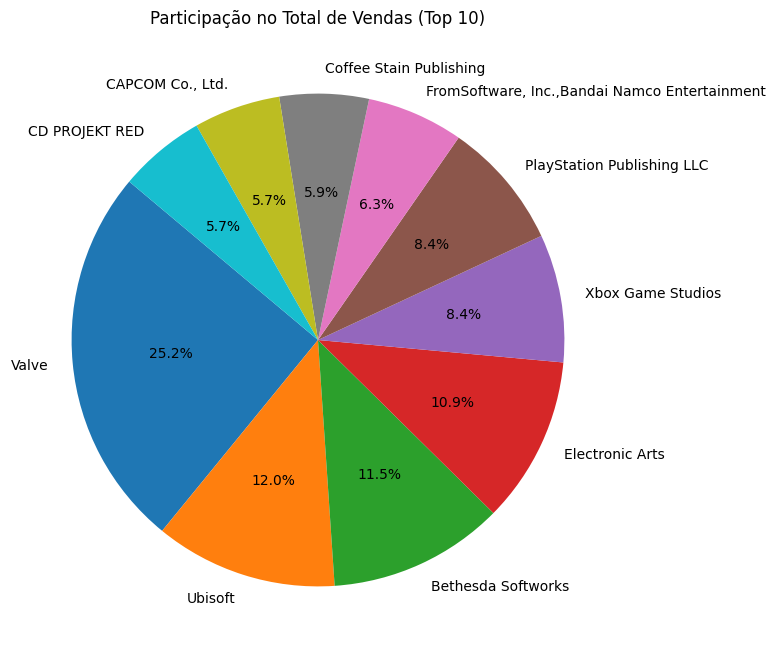

In [31]:
df_grouped = df.groupby('Publishers')[['Total_de_Vendas']].sum()

df_pizza = df_grouped.sort_values(by='Total_de_Vendas', ascending=False).head(10)

plt.figure(figsize=(8, 8)) 
df_pizza['Total_de_Vendas'].plot(kind='pie', autopct='%1.1f%%', startangle=140, legend=False)


plt.title('Participação no Total de Vendas (Top 10)')
plt.ylabel('') 
plt.show()